In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Iniciando o pipeline de Machine Learning...")

# 1. Leitura da base enriquecida
df = pd.read_csv('../data/processed/base_logistica_enriquecida.csv')

Iniciando o pipeline de Machine Learning...


In [2]:
# 2. Seleção de Features (As variáveis que o modelo vai usar para aprender)
# Nota: Deixamos 'rota_logistica' para o Power BI e usamos os estados separados aqui para otimizar o algoritmo
features = [
    'seller_state', 'customer_state', 'product_weight_g', 
    'volume_cm3', 'mes_compra', 'dia_semana_compra'
]

X = df[features].copy()
y = df['houve_atraso']

In [3]:
# 3. Pré-processamento (One-Hot Encoding)
# Transformando as siglas dos estados (SP, RJ) em colunas numéricas (0 ou 1)
X = pd.get_dummies(X, columns=['seller_state', 'customer_state'], drop_first=True)

print(f"Dimensões das variáveis preditivas após conversão: {X.shape}")

Dimensões das variáveis preditivas após conversão: (110179, 51)


In [4]:
# 4. Divisão de Treino e Teste (70% para estudar, 30% para a prova final)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [5]:
# 5. Treinamento do Modelo (Random Forest)
# Utilizamos class_weight='balanced' para ele prestar atenção nos atrasos, que são a minoria dos casos
modelo_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1 # Usa todos os núcleos do seu processador
)

print("Treinando a Floresta Aleatória. Isso pode levar alguns segundos...")
modelo_rf.fit(X_train, y_train)

Treinando a Floresta Aleatória. Isso pode levar alguns segundos...


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat


--- Relatório de Performance no Teste ---
              precision    recall  f1-score   support

           0       0.96      0.82      0.89     30875
           1       0.17      0.53      0.26      2179

    accuracy                           0.80     33054
   macro avg       0.57      0.67      0.57     33054
weighted avg       0.91      0.80      0.84     33054



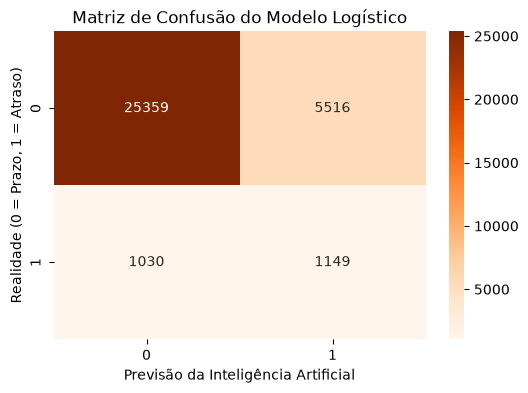

In [6]:
# 6. Avaliação do Modelo
y_pred = modelo_rf.predict(X_test)
print("\n--- Relatório de Performance no Teste ---")
print(classification_report(y_test, y_pred))

# Plotando a Matriz de Confusão para o seu Notebook ficar visual
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão do Modelo Logístico')
plt.ylabel('Realidade (0 = Prazo, 1 = Atraso)')
plt.xlabel('Previsão da Inteligência Artificial')
plt.show()

In [7]:
# 7. Exportação da Vitrine para o Power BI
# Calculando a PROBABILIDADE de atraso (0 a 100%) para a base inteira
probabilidades = modelo_rf.predict_proba(X)[:, 1]

# Criamos uma cópia limpa do DataFrame original e adicionamos o risco
df_powerbi = df.copy()
df_powerbi['risco_atraso_perc'] = (probabilidades * 100).round(2)

# Salvando a base final
caminho_bi = '../data/processed/base_para_powerbi.csv'
df_powerbi.to_csv(caminho_bi, index=False)

print(f"\nSucesso! Arquivo final gerado com as previsões de IA em: {caminho_bi}")


Sucesso! Arquivo final gerado com as previsões de IA em: ../data/processed/base_para_powerbi.csv
